# Exploratory Data Analysis

### Libraries

In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels
from scipy.stats import linregress

import sys
print(sys.executable)

/Users/zana/Desktop/PROGRAMMING Files/HormoneAnalysis/.venv/bin/python


### Graph Style Definition

In [67]:
sns.set_style("whitegrid")
sns.set_palette('viridis', n_colors=7)

### Data Loading

In [68]:
demo = pd.read_sas("DEMO_L.xpt")
biochem = pd.read_sas("BIOPRO_L.xpt")
trigly = pd.read_sas("TRIGLY_L.xpt")
chol_h = pd.read_sas("HDL_L.xpt")
tst = pd.read_sas("TST_L.xpt")

### Web Source
- [Link](https://wwwn.cdc.gov/nchs/nhanes/search/datapage.aspx?Component=Laboratory&Cycle=2021-2023)

### Tables Used and Variables Chosen to Observe
- Demographic Variables and Sample Weights -> `DEMO_L.xpt` -> `demo`
    - [RIAGENDR - Gender](https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/DEMO_L.htm#RIAGENDR) -> `gender`
    - [RIDAGEYR - Age in years at screening](https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/DEMO_L.htm#RIDAGEYR) -> `age`
- Standard Biochemistry Profile -> `BIOPRO_L.xpt` -> `biochem`
    - [LBDSGLSI - Glucose, refrigerated serum (mmol/L)](https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/BIOPRO_L.htm#LBDSGLSI) -> `glu`
    - [LBDSTRSI - Triglycerides, refrig serum (mmol/L)](https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/BIOPRO_L.htm#LBDSTRSI) -> `tg_s` -> NOT USED????
- Cholesterol - Low-Density Lipoproteins (LDL) & Triglycerides -> `TRIGLY_L.xpt` -> `trigly`
    - [LBDTRSI - Triglyceride (mmol/L)](https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/TRIGLY_L.htm#LBDTRSI) -> `tg`
- Cholesterol – High-Density Lipoprotein (HDL_L) -> `HDL_L.xpt` -> `chol_h`
    - [LBDHDDSI - Direct HDL-Cholesterol (mmol/L)](https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/HDL_L.htm#LBDHDDSI) -> `hdl`
- Sex Steroid Hormone Panel - Serum -> `TST_L_Data.xpt` -> `tst`
    - [LBDESTSI - Estradiol (pmol/L)](https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/TST_L.htm#LBDESTSI) -> `estr`
    - [LBDTSTSI - Testosterone, total (nmol/L)](https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/TST_L.htm#LBDTSTSI) -> `tstn`
    - [LBXSHBG - SHBG (nmol/L)](https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/TST_L.htm#LBXSHBG) -> `shbg`
### Identifier Between the Tables -> `SEQN` -> `id`

# Data Exploration and Cleaning
### Joining Tables

In [69]:
demo = demo[["SEQN", "RIAGENDR", "RIDAGEYR"]]
biochem = biochem[["SEQN", "LBDSGLSI"]]
trigly = trigly[["SEQN", "LBDTRSI"]]
chol_h = chol_h[["SEQN", "LBDHDDSI"]]
tst = tst[["SEQN", "LBDESTSI", "LBDTSTSI", "LBXSHBG"]]

df = (demo
      .merge(biochem, on="SEQN")
      .merge(trigly, on="SEQN")
      .merge(chol_h, on="SEQN")
      .merge(tst, on="SEQN")
)
df.head()

,SEQN,RIAGENDR,RIDAGEYR,LBDSGLSI,LBDTRSI,LBDHDDSI,LBDESTSI,LBDTSTSI,LBXSHBG
0,130378.0,1.0,43.0,6.0,1.727,1.16,89.5,23.200,23.94
1,130379.0,1.0,66.0,5.0,0.971,1.55,92.5,15.200,57.46
2,130380.0,2.0,44.0,8.0,4.234,1.27,312.0,0.479,52.01
3,130386.0,1.0,34.0,5.0,1.603,1.19,51.4,16.400,40.83
4,130394.0,1.0,51.0,5.0,0.644,1.24,71.6,18.100,38.05


In [70]:
df = df.rename(columns={
    "SEQN": "id",
    "RIAGENDR": "gender",
    "RIDAGEYR": "age",
    "LBDSGLSI": "glu",
    "LBDTRSI": "tg",
    "LBDHDDSI": "hdl",
    "LBDESTSI": "estr",
    "LBDTSTSI": "tstn",
    "LBXSHBG": "shbg"
})
df.head()

,id,gender,age,glu,tg,hdl,estr,tstn,shbg
0,130378.0,1.0,43.0,6.0,1.727,1.16,89.5,23.200,23.94
1,130379.0,1.0,66.0,5.0,0.971,1.55,92.5,15.200,57.46
2,130380.0,2.0,44.0,8.0,4.234,1.27,312.0,0.479,52.01
3,130386.0,1.0,34.0,5.0,1.603,1.19,51.4,16.400,40.83
4,130394.0,1.0,51.0,5.0,0.644,1.24,71.6,18.100,38.05


In [71]:
numeric_columns = ['age', 'glu', 'tg', 'hdl', 'estr', 'tstn', 'shbg']
df[numeric_columns].describe().round()

,age,glu,tg,hdl,estr,tstn,shbg
count,3996.0,3527.0,3517.0,3546.0,3585.0,3589.0,3605.0
mean,49.0,6.0,1.0,1.0,247.0,8.0,53.0
std,21.0,2.0,1.0,0.0,1759.0,10.0,44.0
min,12.0,2.0,0.0,1.0,4.0,0.0,5.0
25%,31.0,5.0,1.0,1.0,32.0,1.0,29.0
50%,52.0,5.0,1.0,1.0,80.0,2.0,43.0
75%,66.0,6.0,2.0,2.0,133.0,15.0,64.0
max,80.0,50.0,20.0,4.0,45100.0,137.0,672.0


In [72]:
df[['id', 'gender', 'age']].astype(int)

,id,gender,age
0,130378,1,43
1,130379,1,66
2,130380,2,44
3,130386,1,34
4,130394,1,51
...,...,...,...
3991,142301,2,80
3992,142303,2,69
3993,142305,2,76
3994,142308,1,50


In [73]:
gender_dict = {1: 'male', 2: 'female'}
df['gender'] = df['gender'].map(gender_dict)
df.head()

,id,gender,age,glu,tg,hdl,estr,tstn,shbg
0,130378.0,male,43.0,6.0,1.727,1.16,89.5,23.200,23.94
1,130379.0,male,66.0,5.0,0.971,1.55,92.5,15.200,57.46
2,130380.0,female,44.0,8.0,4.234,1.27,312.0,0.479,52.01
3,130386.0,male,34.0,5.0,1.603,1.19,51.4,16.400,40.83
4,130394.0,male,51.0,5.0,0.644,1.24,71.6,18.100,38.05


In [74]:
df.isna().sum()

id          0
gender      0
age         0
glu       469
tg        479
hdl       450
estr      411
tstn      407
shbg      391
dtype: int64

In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3996 entries, 0 to 3995
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      3996 non-null   float64
 1   gender  3996 non-null   str    
 2   age     3996 non-null   float64
 3   glu     3527 non-null   float64
 4   tg      3517 non-null   float64
 5   hdl     3546 non-null   float64
 6   estr    3585 non-null   float64
 7   tstn    3589 non-null   float64
 8   shbg    3605 non-null   float64
dtypes: float64(8), str(1)
memory usage: 281.1 KB


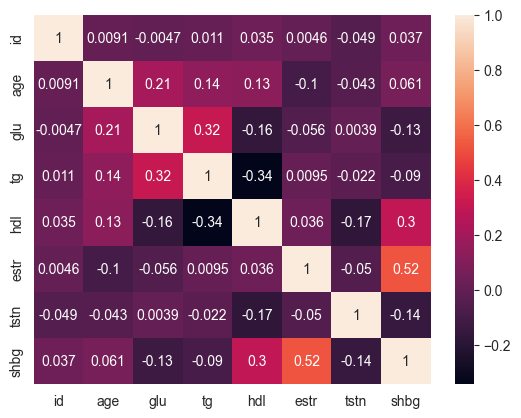

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

### Correlation for Females' Metrics

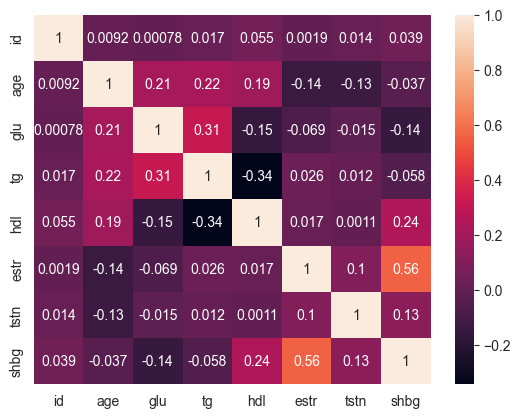

In [94]:
df_f = df[df['gender'] == 'female']
sns.heatmap(df_f.corr(numeric_only=True), annot=True)
plt.show()

- for females, it could be worth to investigate correlation of 
    - age <-> glu
    - age <-> tg
    - shbg <-> hdl
    - shbg <-> estr
    - hdl <-> tg
- we are interested only in correlations of |ρ| > 0.2
### Correlation for Males' Metrics

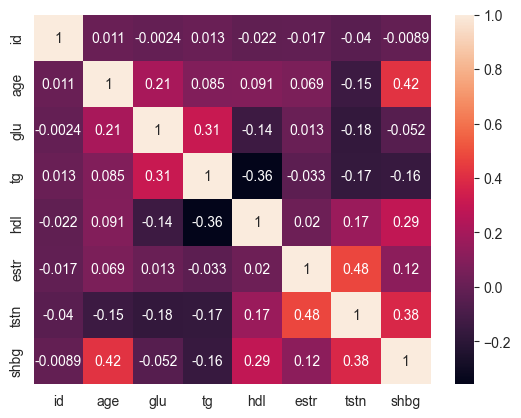

In [95]:
df_m = df[df['gender'] == 'male']
sns.heatmap(df_m.corr(numeric_only=True), annot=True)
plt.show()

- for males, it could be worth to investigate correlation of
    - age <-> glu
    - age <-> shbg
    - glu <-> tg
    - tg <-> hdl
    - hdl <-> shbg
    - tstn <-> estr
    - tstn <-> shbg
- we are interested only in correlations of |ρ| > 0.2

# 1. Hormones vs Age

**Research question**: How do hormonal values vary between individuals of different ages?

**We explore relationships between**:
- estradiol-age
- testosterone-age
- SHBG-age

Distribution of age data:

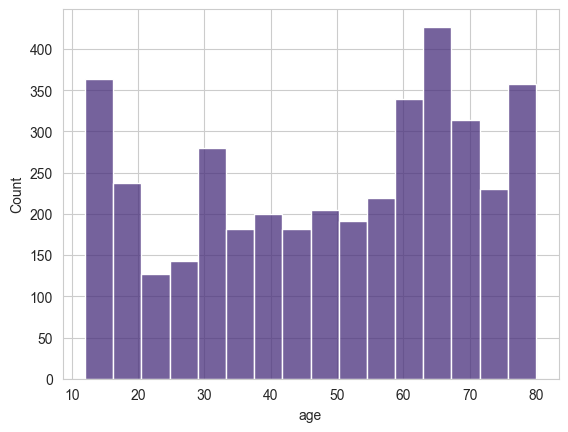

In [76]:
sns.histplot(x='age', data=df)
plt.show()

Individual variables relationship are studied with all data available for that particular variable, therefore missing values are handled only at this point

In [80]:
df_estr = df[['gender', 'age', 'estr']]
df_estr.dropna(subset=['age', 'estr'])
df_estr.isna().sum()

gender      0
age         0
estr      411
dtype: int64

In [81]:
df_estr['gender'].value_counts()
df_estr.head()

,gender,age,estr
0,male,43.0,89.5
1,male,66.0,92.5
2,female,44.0,312.0
3,male,34.0,51.4
4,male,51.0,71.6


### Estradiol

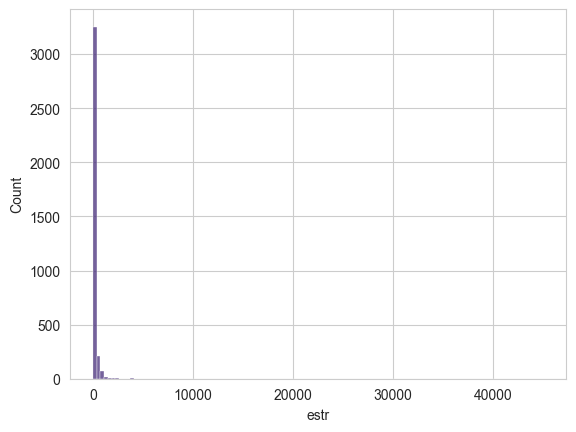

In [82]:
sns.histplot(x='estr', data=df_estr)
plt.show()

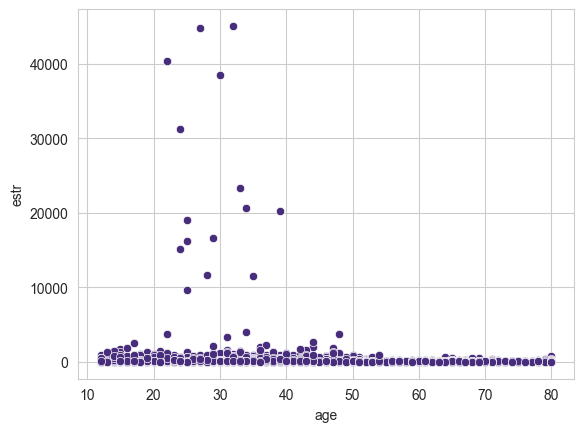

In [83]:
sns.scatterplot(x='age', y='estr', data=df_estr)
plt.show()

In [84]:
sf = df_estr['estr'].quantile(0.75)
tf = df_estr['estr'].quantile(0.25)
IQR = sf - tf

upper = sf + (1.5 * IQR)
lower = tf - (1.5 * IQR)

print('Length with outliers:', len(df_estr))
print('Deleted:', len(df_estr[(df_estr['estr'] < lower) | (df_estr['estr'] > upper)]))
df_estr_no_outliers = df_estr[(df_estr['estr'] > lower) & (df_estr['estr'] < upper)]

Length with outliers: 3996
Deleted: 435


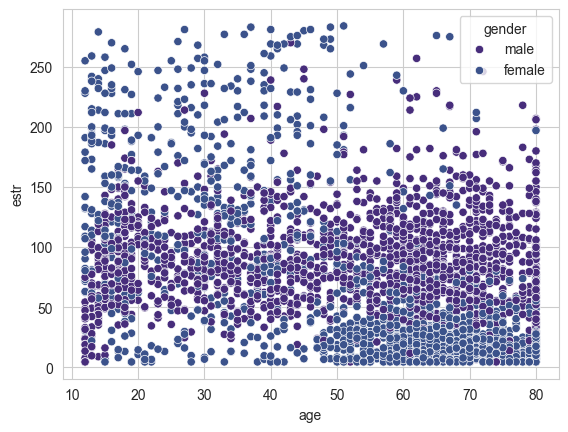

In [85]:
sns.scatterplot(x='age', y='estr', data=df_estr_no_outliers, hue='gender')
plt.show()

- Estradiol doesn't seem to neither increase, nor decrease throughout the life in men.
- In women, although there is not a continual increasse/decrease, there is an observable drop after around 45-55 years.

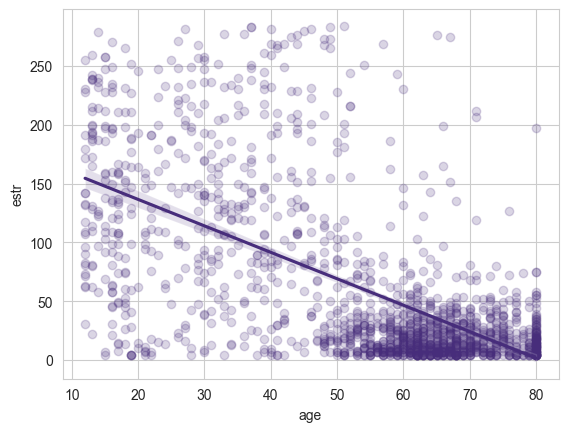

In [122]:
sns.regplot(
    data=df_estr_no_outliers[df_estr_no_outliers['gender'] == 'female'],
    x='age',
    y='estr',
    scatter_kws={'alpha':0.2}
)
plt.show()

- more appropriate trend:

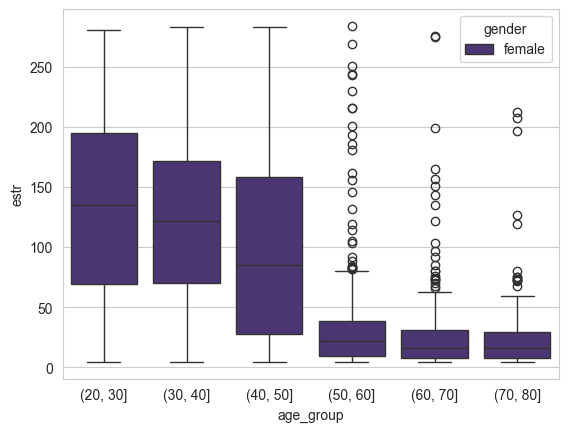

In [123]:
df_estr_fem = df_estr_no_outliers[df_estr_no_outliers['gender'] == 'female']

df_estr_fem['age_group'] = pd.cut(
    df_estr_fem['age'],
    bins=[20,30,40,50,60,70,80]
)

sns.boxplot(
    data=df_estr_fem,
    x='age_group',
    y='estr',
    hue='gender'
)
plt.show()

In [ ]:
linregress(df_estr_fem['age'], df_estr_fem['estr'])

LinregressResult(slope=np.float64(-2.2475959716170597), intercept=np.float64(181.46741484790277), rvalue=np.float64(-0.6145509520548725), pvalue=np.float64(8.807037928204476e-160), stderr=np.float64(0.07376052513366504), intercept_stderr=np.float64(4.190147204817367))

Estradiol decreased by approximately 2.25 pmol/L per year in females.

### Testosterone

NA Values: gender    0
age       0
tstn      0
dtype: int64


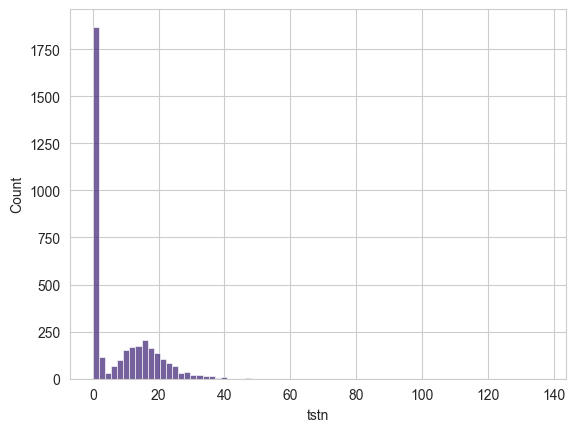

Length with outliers: 3589
Deleted: 24


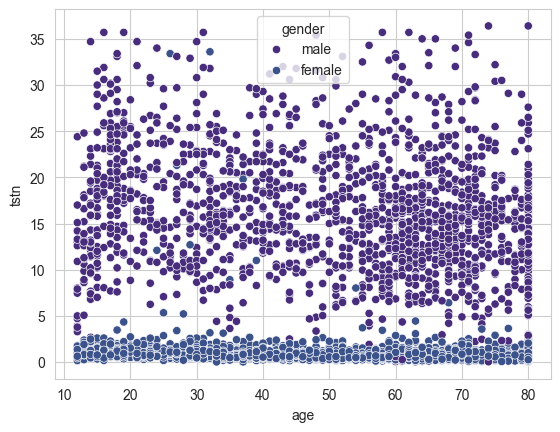

In [140]:
def prepare_df(df: pd.DataFrame, col: str, del_out=False):
    name = str(col)
    new_df = df[['gender', 'age', col]]
    new_df = new_df.dropna(subset=['age', col])
    print('NA Values:', new_df.isna().sum())
    sns.histplot(x=col, data=new_df)
    plt.show()
    
    if del_out:
        new_df_no_outliers = delete_outliers(new_df, col)
        sns.scatterplot(x='age', y=col, data=new_df_no_outliers, hue='gender')
    else: 
        sns.scatterplot(x='age', y=col, data=new_df, hue='gender')
    plt.show()
    return new_df

def delete_outliers(df, col):
    sf = df[col].quantile(0.75)
    tf = df[col].quantile(0.25)
    IQR = sf - tf

    upper = sf + (1.5 * IQR)
    lower = tf - (1.5 * IQR)

    print('Length with outliers:', len(df))
    print('Deleted:', len(df[(df[col] < lower) | (df[col] > upper)]))
    df_no_outliers = df[(df[col] > lower) & (df[col] < upper)]

    return df_no_outliers

df_tstn = prepare_df(df, 'tstn', del_out=True)

- Testosterone is lower in women than in men, but no trend is visually apparent for neither sex.

### SHBG

NA Values: gender    0
age       0
shbg      0
dtype: int64


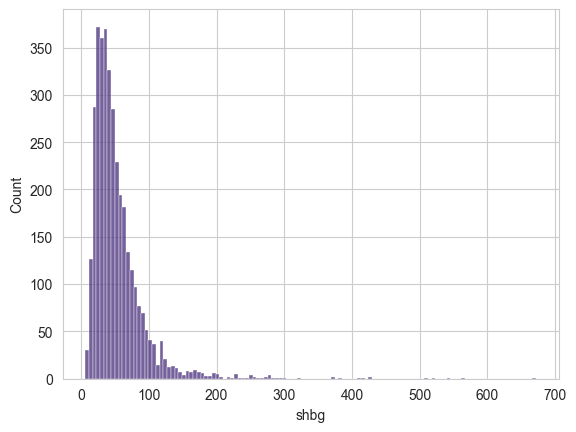

Length with outliers: 3605
Deleted: 195


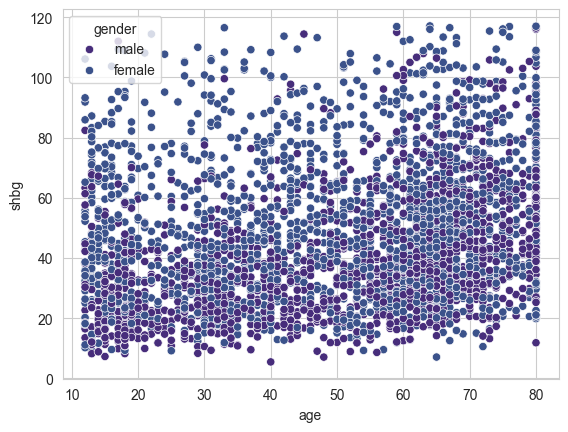

In [141]:
df_shbg = prepare_df(df, 'shbg', del_out=True)

- SHBG may have a slight correlation with age for men.

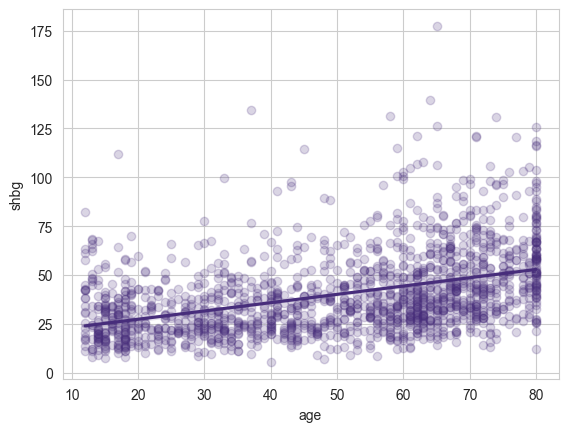

In [142]:
sns.regplot(
    data=df_shbg[df_shbg['gender'] == 'male'],
    x='age',
    y='shbg',
    scatter_kws={'alpha':0.2}
)
plt.show()

In [145]:
df_shbg_m = df_shbg[df_shbg['gender'] == 'male']
linregress(df_shbg_m['age'], df_shbg_m['shbg'])

LinregressResult(slope=np.float64(0.42485327787033844), intercept=np.float64(18.841934934056113), rvalue=np.float64(0.41726565858711245), pvalue=np.float64(1.231566421653469e-69), stderr=np.float64(0.02294000413181639), intercept_stderr=np.float64(1.241205255056622))

SHBG in men is rising with age by 0.42 nmol/L.
# 2. Hormones vs Metabolic Syndrome Biomarkers